<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Recurrent Neural Networks (RNN) Regression
</p>

#### Purpose and evaluation protocol

This notebook implements a time-aware RNN pipeline for path loss prediction using fixed-length sequences. The evaluation design follows strict temporal separation to avoid leakage.

Key principles:
- Train/test split is time-ordered (train window precedes test window).
- Model selection is done via time-aware cross-validation on the training window only.
- Feature scaling is fit on the training window and applied to validation/test.
- Sequences are built within folds to avoid leakage across time boundaries.
- The held-out test window is used once for final reporting.

Metrics reported: MSE, MAE, RMSE, R2, MAPE, Median AE.

In [1]:
# Imports - core utils, data wrangling, RNN modeling, evaluation, and plotting

# Standard library
import ast
import os
import pickle
import re
import time

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.colors import qualitative
from plotly.subplots import make_subplots

# TensorFlow / Keras
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import BatchNormalization, Dense, Dropout, Input, LeakyReLU, SimpleRNN
from keras.models import Sequential
from keras.regularizers import l2
from tensorflow.keras import backend as K

# ML evaluation and splitting
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.preprocessing import StandardScaler

# Reproducibility
GLOBAL_SEED = 50
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)


In [2]:
# Paths 
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "rnn_kfold_results_summary.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "rnn_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)
fold_assignments = np.asarray(fold_assignments).ravel()
cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]


# Datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

feature_columns = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_column = "PL"

required_cols = [target_column, "device_id", *feature_columns]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

# Raw features only. Scaling is fit inside each CV fold or final training window.
X_train_df = df_train[feature_columns].copy()
X_test_df  = df_test[feature_columns].copy()

X_train_all = X_train_df.to_numpy()
X_test_all  = X_test_df.to_numpy()
PL_train_all = df_train[target_column].astype(float).to_numpy()
PL_test_all  = df_test[target_column].astype(float).to_numpy()

X_train = X_train_all
X_test = X_test_all
y_train = PL_train_all
y_test = PL_test_all

# Time-aware folds
# Hold out the most recent training fold for final early-stopping validation
fold_ids = np.unique(fold_assignments)
fold_ids = fold_ids[fold_ids >= 0]
if fold_ids.size == 0:
    raise ValueError("fold_assignments must contain at least one non-negative fold id.")

val_fold = fold_ids.max()
val_mask = fold_assignments == val_fold

X_train_time_raw = X_train_all[~val_mask]
y_train_time = PL_train_all[~val_mask]
X_val_time_raw = X_train_all[val_mask]
y_val_time = PL_train_all[val_mask]

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")
print(f"Validation fold for final early stopping: {val_fold} (rows: {val_mask.sum()})")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))
print("Time-based split prepared; scaling is fit inside folds and on the final train window only.")


Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Validation fold for final early stopping: 4 (rows: 277271)
Fold sizes: {np.int64(0): np.int64(554543), np.int64(1): np.int64(277271), np.int64(2): np.int64(277271), np.int64(3): np.int64(277271), np.int64(4): np.int64(277271)}
Time-based split prepared; scaling is fit inside folds and on the final train window only.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Model Definition
</p>

In [3]:
# Sequence settings
SEQ_LEN = 10
RNN_UNITS_LIST = [32, 64, 128]


def make_sequences(X, y, seq_len):
    if len(X) < seq_len:
        raise ValueError(f"Not enough rows to build sequences: {len(X)} < SEQ_LEN={seq_len}")
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
    return np.array(Xs), np.array(ys)


def make_sequence_target_indices(indices, seq_len):
    indices = np.asarray(indices)
    if len(indices) < seq_len:
        return np.array([], dtype=int)
    return indices[seq_len - 1:]


def build_sequences_by_fold_scaled(X_scaled, y, fold_assignments_subset, seq_len):
    X_list, y_list = [], []
    unique_folds = np.unique(fold_assignments_subset)
    for fold_id in unique_folds:
        idx = np.flatnonzero(fold_assignments_subset == fold_id)
        if idx.size < seq_len:
            raise ValueError(f"Fold {fold_id} has {idx.size} rows; SEQ_LEN={seq_len}")
        X_seq, y_seq = make_sequences(X_scaled[idx], y[idx], seq_len)
        X_list.append(X_seq)
        y_list.append(y_seq)
    if not X_list:
        raise ValueError("No sequences were created; check SEQ_LEN or data size.")
    return np.concatenate(X_list), np.concatenate(y_list)


def create_rnn_model(
    layer_units,
    seq_len,
    n_features,
    rnn_units=64,
    l2_reg=1e-4,
    dropout_rate=0.1,
    negative_slope=0.1,
):
    model = Sequential()
    model.add(Input(shape=(seq_len, n_features)))

    model.add(SimpleRNN(rnn_units, activation="tanh", kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))

    for units in layer_units:
        model.add(Dense(units, kernel_regularizer=l2(l2_reg)))
        model.add(LeakyReLU(negative_slope=negative_slope))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="linear"))
    model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])
    return model

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Architecture Grid
</p>

In [4]:
def build_architectures(rnn_units_list):
    archs = []

    for rnn_units in rnn_units_list:
        # 1-layer
        for h1 in [8, 16, 32, 64, 128]:
            archs.append({"name": f"RNN{rnn_units}_L1_{h1}", "units": [h1], "rnn_units": rnn_units})

        # 2-layer funnels
        for h1, h2 in [(32, 16), (64, 32), (128, 64), (64, 16), (128, 32)]:
            archs.append({"name": f"RNN{rnn_units}_L2_{h1}_{h2}", "units": [h1, h2], "rnn_units": rnn_units})

        # 3-layer funnels
        for h1, h2, h3 in [(32, 16, 8), (64, 32, 16), (128, 64, 32), (64, 16, 8), (128, 32, 16)]:
            archs.append({"name": f"RNN{rnn_units}_L3_{h1}_{h2}_{h3}", "units": [h1, h2, h3], "rnn_units": rnn_units})

        # Mauricio-style anchor
        archs.append({"name": f"RNN{rnn_units}_L3_20_10_5", "units": [20, 10, 5], "rnn_units": rnn_units})

    return archs

architectures = build_architectures(RNN_UNITS_LIST)
len(architectures), architectures[:5]

(48,
 [{'name': 'RNN32_L1_8', 'units': [8], 'rnn_units': 32},
  {'name': 'RNN32_L1_16', 'units': [16], 'rnn_units': 32},
  {'name': 'RNN32_L1_32', 'units': [32], 'rnn_units': 32},
  {'name': 'RNN32_L1_64', 'units': [64], 'rnn_units': 32},
  {'name': 'RNN32_L1_128', 'units': [128], 'rnn_units': 32}])

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Time-Aware Cross-Validation (Model Selection)
</p>

In [5]:
t0 = time.time()

# Time-aware cross-validation for each architecture
kfold_results = []
n_splits = len(cv_splits)

for arch in architectures:
    print(f"Performing {n_splits}-Fold CV for Architecture: {arch['name']}")
    fold_metrics = []

    for fold_num, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        print(f"  Fold {fold_num}/{n_splits}...")

        train_idx = np.sort(train_idx)
        val_idx = np.sort(val_idx)

        X_train_fold_raw = X_train_all[train_idx]
        y_train_fold = PL_train_all[train_idx]
        folds_train = fold_assignments[train_idx]

        X_val_fold_raw = X_train_all[val_idx]
        y_val_fold = PL_train_all[val_idx]
        folds_val = fold_assignments[val_idx]

        # Fold-wise scaling: fit only on current train fold set
        scaler_fold = StandardScaler()
        X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold_raw)
        X_val_fold_scaled = scaler_fold.transform(X_val_fold_raw)

        # Build sequences within each fold
        X_train_seq, y_train_seq = build_sequences_by_fold_scaled(
            X_train_fold_scaled, y_train_fold, folds_train, SEQ_LEN
        )
        X_val_seq, y_val_seq = build_sequences_by_fold_scaled(
            X_val_fold_scaled, y_val_fold, folds_val, SEQ_LEN
        )

        K.clear_session()
        tf.random.set_seed(GLOBAL_SEED + fold_num)

        model_cv = create_rnn_model(
            layer_units=arch["units"],
            seq_len=SEQ_LEN,
            n_features=X_train_fold_scaled.shape[1],
            rnn_units=arch["rnn_units"],
            l2_reg=0.001,
            dropout_rate=0.3,
            negative_slope=0.1,
        )

        early_stop_cv = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        reduce_lr_cv = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0)

        model_cv.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100,
            batch_size=128,
            verbose=0,
            callbacks=[early_stop_cv, reduce_lr_cv],
            shuffle=False,
        )

        val_loss_cv, val_mae_cv = model_cv.evaluate(X_val_seq, y_val_seq, verbose=0)
        val_pred = model_cv.predict(X_val_seq, verbose=0).flatten()

        rmse_cv = np.sqrt(mean_squared_error(y_val_seq, val_pred))
        r2_cv = r2_score(y_val_seq, val_pred)
        mape_cv = mean_absolute_percentage_error(y_val_seq, val_pred) * 100
        median_ae_cv = median_absolute_error(y_val_seq, val_pred)

        fold_metrics.append({
            "Fold": fold_num,
            "Val MSE": val_loss_cv,
            "Val MAE": val_mae_cv,
            "Val RMSE": rmse_cv,
            "R2 Score": r2_cv,
            "Val MAPE (%)": mape_cv,
            "Val Median AE": median_ae_cv,
        })

        print(
            f" Fold {fold_num} Metrics - Val MSE: {val_loss_cv:.4f} | "
            f"Val RMSE: {rmse_cv:.4f} | R2: {r2_cv:.4f} | MAPE: {mape_cv:.2f}%"
        )

    arch_cv_df = pd.DataFrame(fold_metrics)
    arch_cv_mean = arch_cv_df.mean(numeric_only=True)
    arch_cv_std = arch_cv_df.std(numeric_only=True)

    kfold_results.append({
        "Architecture": arch["name"],
        "Hidden Layers": str(arch["units"]),
        "RNN Units": arch["rnn_units"],
        "Mean Val MSE": arch_cv_mean["Val MSE"],
        "Std Val MSE": arch_cv_std["Val MSE"],
        "Mean Val MAE": arch_cv_mean["Val MAE"],
        "Std Val MAE": arch_cv_std["Val MAE"],
        "Mean Val RMSE": arch_cv_mean["Val RMSE"],
        "Std Val RMSE": arch_cv_std["Val RMSE"],
        "Mean R2": arch_cv_mean["R2 Score"],
        "Std R2": arch_cv_std["R2 Score"],
        "Mean Val MAPE (%)": arch_cv_mean["Val MAPE (%)"],
        "Std Val MAPE (%)": arch_cv_std["Val MAPE (%)"],
        "Mean Val MedAE": arch_cv_mean["Val Median AE"],
        "Std Val MedAE": arch_cv_std["Val Median AE"],
    })

kfold_results_df = pd.DataFrame(kfold_results)
kfold_results_df_sorted = kfold_results_df.sort_values(by="Mean Val RMSE", ascending=True)
print("\nTime-aware CV summary (sorted by Mean Val RMSE):")
display(kfold_results_df_sorted.head())

kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nCV results saved to: {CV_RESULTS_PATH}")

# Select the best architecture by CV
best_arch_name = kfold_results_df_sorted.iloc[0]["Architecture"]
best_arch_units = next(a["units"] for a in architectures if a["name"] == best_arch_name)
best_rnn_units = next(a["rnn_units"] for a in architectures if a["name"] == best_arch_name)
print(f"\nSelected architecture: {best_arch_name} with layers {best_arch_units} and RNN units {best_rnn_units}")

t1 = time.time()
print(f"\nRNN CV complete in {(t1 - t0) / 60:.2f} minutes.")


Performing 5-Fold CV for Architecture: RNN32_L1_8
  Fold 1/5...
 Fold 1 Metrics - Val MSE: 41.5142 | Val RMSE: 6.4030 | R2: 0.8856 | MAPE: 5.74%
  Fold 2/5...
 Fold 2 Metrics - Val MSE: 44.0040 | Val RMSE: 6.5950 | R2: 0.8789 | MAPE: 6.14%
  Fold 3/5...
 Fold 3 Metrics - Val MSE: 45.9738 | Val RMSE: 6.7440 | R2: 0.8577 | MAPE: 5.94%
  Fold 4/5...
 Fold 4 Metrics - Val MSE: 46.4549 | Val RMSE: 6.7883 | R2: 0.8849 | MAPE: 6.44%
  Fold 5/5...
 Fold 5 Metrics - Val MSE: 31.0870 | Val RMSE: 5.5350 | R2: 0.9058 | MAPE: 5.09%
Performing 5-Fold CV for Architecture: RNN32_L1_16
  Fold 1/5...
 Fold 1 Metrics - Val MSE: 38.6862 | Val RMSE: 6.1797 | R2: 0.8934 | MAPE: 5.38%
  Fold 2/5...
 Fold 2 Metrics - Val MSE: 43.9753 | Val RMSE: 6.5957 | R2: 0.8789 | MAPE: 6.13%
  Fold 3/5...
 Fold 3 Metrics - Val MSE: 44.9361 | Val RMSE: 6.6674 | R2: 0.8610 | MAPE: 5.88%
  Fold 4/5...
 Fold 4 Metrics - Val MSE: 43.8746 | Val RMSE: 6.5924 | R2: 0.8914 | MAPE: 6.27%
  Fold 5/5...
 Fold 5 Metrics - Val MSE: 29.

,Architecture,Hidden Layers,RNN Units,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Mean Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE
4,RNN32_L1_128,[128],32,36.270824,5.451299,4.507341,0.353380,5.969094,0.466017,0.898125,0.016292,5.337424,0.443927,3.626637,0.313951
40,RNN128_L2_64_16,"[64, 16]",128,37.883118,6.976403,4.689247,0.502904,6.070487,0.585915,0.894536,0.019253,5.551079,0.623298,3.896416,0.521433
30,RNN64_L3_128_32_16,"[128, 32, 16]",64,38.071603,7.357717,4.655399,0.516791,6.093735,0.620827,0.893654,0.020475,5.487108,0.627158,3.785106,0.499719
27,RNN64_L3_64_32_16,"[64, 32, 16]",64,38.469569,7.987017,4.663889,0.527351,6.119547,0.663640,0.892396,0.024038,5.469009,0.611290,3.816877,0.482220
20,RNN64_L1_128,[128],64,38.386034,6.725991,4.654722,0.492472,6.125799,0.561267,0.892015,0.024207,5.498799,0.555933,3.767116,0.521124



CV results saved to: CV_Results/rnn_kfold_results_summary.csv

Selected architecture: RNN32_L1_128 with layers [128] and RNN units 32

RNN CV complete in 2762.33 minutes.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Full Training and Test Evaluation
</p>

In [6]:
t2 = time.time()

# Fallback: load saved CV summary if this session did not just run the CV cell.
if "best_arch_units" not in locals() or "best_arch_name" not in locals() or "best_rnn_units" not in locals():
    legacy_cv_result_paths = [
        os.path.join("RNN", "Results", "kfold_results_summary.csv"),
        os.path.join("Results", "kfold_results_summary.csv"),
    ]

    if os.path.exists(CV_RESULTS_PATH):
        kfold_results_df_sorted = pd.read_csv(CV_RESULTS_PATH)
    else:
        kfold_results_df_sorted = None
        for legacy_path in legacy_cv_result_paths:
            if os.path.exists(legacy_path):
                kfold_results_df_sorted = pd.read_csv(legacy_path)
                kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
                print(f"Migrated legacy RNN CV results to: {CV_RESULTS_PATH}")
                break

        if kfold_results_df_sorted is None:
            raise FileNotFoundError(
                f"No RNN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
            )

    kfold_results_df_sorted = kfold_results_df_sorted.sort_values(by="Mean Val RMSE", ascending=True)
    best_arch_name = kfold_results_df_sorted.iloc[0]["Architecture"]
    best_arch_units = ast.literal_eval(kfold_results_df_sorted.iloc[0]["Hidden Layers"])
    best_rnn_units = int(kfold_results_df_sorted.iloc[0]["RNN Units"])
    print(
        f"Loaded selected architecture from CV results: {best_arch_name} "
        f"with layers {best_arch_units} and RNN units {best_rnn_units}"
    )

# Leak-free scaling for the final train/validation/test stage
X_train_time_raw = X_train_all[train_time_idx]
X_val_time_raw = X_train_all[val_time_idx]

scaler_final = StandardScaler()
X_train_time_scaled = scaler_final.fit_transform(X_train_time_raw)
X_val_time_scaled = scaler_final.transform(X_val_time_raw)
X_test_all_scaled = scaler_final.transform(X_test_all)

# Build sequences within train and validation folds
folds_train_time = fold_assignments[~val_mask]
folds_val_time = fold_assignments[val_mask]

X_train_seq, y_train_seq = build_sequences_by_fold_scaled(
    X_train_time_scaled, y_train_time, folds_train_time, SEQ_LEN
)
X_val_seq, y_val_seq = build_sequences_by_fold_scaled(
    X_val_time_scaled, y_val_time, folds_val_time, SEQ_LEN
)

if len(X_test_all_scaled) < SEQ_LEN:
    raise ValueError(f"Test set too small for SEQ_LEN={SEQ_LEN}")
X_test_seq, PL_test_seq = make_sequences(X_test_all_scaled, PL_test_all, SEQ_LEN)
test_target_idx = np.arange(SEQ_LEN - 1, len(df_test), dtype=int)

K.clear_session()
tf.random.set_seed(GLOBAL_SEED)

final_model = create_rnn_model(
    layer_units=best_arch_units,
    seq_len=SEQ_LEN,
    n_features=X_train_time_scaled.shape[1],
    rnn_units=best_rnn_units,
    l2_reg=0.001,
    dropout_rate=0.3,
    negative_slope=0.1,
)

early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)

history_final = final_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=500,
    batch_size=128,
    verbose=0,
    callbacks=[early_stop, reduce_lr],
    shuffle=False,
)

# Held-out test evaluation
final_test_mse, final_test_mae = final_model.evaluate(X_test_seq, PL_test_seq, verbose=0)
PL_pred_test = final_model.predict(X_test_seq, verbose=0).flatten()
resid_test = PL_test_seq - PL_pred_test

final_test_rmse = np.sqrt(mean_squared_error(PL_test_seq, PL_pred_test))
final_test_r2 = r2_score(PL_test_seq, PL_pred_test)
final_test_mape = mean_absolute_percentage_error(PL_test_seq, PL_pred_test) * 100
final_test_median_ae = median_absolute_error(PL_test_seq, PL_pred_test)

# OOF predictions using the selected architecture. Predictions are assigned to sequence target rows.
y_pred_oof = np.full(len(PL_train_all), np.nan, dtype=float)
if not cv_splits:
    raise ValueError("No validation splits found for OOF residual generation.")

for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
    tr_idx = np.sort(tr_idx)
    val_idx = np.sort(val_idx)

    scaler_fold = StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_all[tr_idx])
    X_val_fold_scaled = scaler_fold.transform(X_train_all[val_idx])

    folds_train = fold_assignments[tr_idx]
    X_train_fold_seq, y_train_fold_seq = build_sequences_by_fold_scaled(
        X_train_fold_scaled, PL_train_all[tr_idx], folds_train, SEQ_LEN
    )

    X_val_fold_seq, y_val_fold_seq = make_sequences(X_val_fold_scaled, PL_train_all[val_idx], SEQ_LEN)
    val_target_idx = make_sequence_target_indices(val_idx, SEQ_LEN)

    K.clear_session()
    tf.random.set_seed(GLOBAL_SEED + int(fold_num))

    fold_model = create_rnn_model(
        layer_units=best_arch_units,
        seq_len=SEQ_LEN,
        n_features=X_train_fold_scaled.shape[1],
        rnn_units=best_rnn_units,
        l2_reg=0.001,
        dropout_rate=0.3,
        negative_slope=0.1,
    )

    fold_early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
    fold_reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)

    fold_model.fit(
        X_train_fold_seq,
        y_train_fold_seq,
        validation_data=(X_val_fold_seq, y_val_fold_seq),
        epochs=500,
        batch_size=128,
        verbose=0,
        callbacks=[fold_early_stop, fold_reduce_lr],
        shuffle=False,
    )

    y_pred_oof[val_target_idx] = fold_model.predict(X_val_fold_seq, verbose=0).flatten()

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = PL_train_all[mask] - PL_pred_oof

print(f"OOF sequence residuals generated for {mask.sum()} of {len(PL_train_all)} training rows.")

final_oof_rmse = np.sqrt(mean_squared_error(PL_train_all[mask], PL_pred_oof))
final_oof_r2 = r2_score(PL_train_all[mask], PL_pred_oof)

final_results_df = pd.DataFrame([
    {
        "Architecture": best_arch_name,
        "Hidden Layers": str(best_arch_units),
        "RNN Units": best_rnn_units,
        "SEQ_LEN": SEQ_LEN,
        "OOF RMSE": final_oof_rmse,
        "OOF R2": final_oof_r2,
        "Test MSE": final_test_mse,
        "Test MAE": final_test_mae,
        "Test RMSE": final_test_rmse,
        "Test R2": final_test_r2,
        "Test MAPE (%)": final_test_mape,
        "Test Median AE": final_test_median_ae,
    }
])

print("Final RNN evaluation:")
display(final_results_df)

# Save final model bundle
rnn_bundle = {
    "best_arch_name": best_arch_name,
    "best_arch_units": best_arch_units,
    "seq_len": int(SEQ_LEN),
    "rnn_units": int(best_rnn_units),
    "n_features": int(X_train_all.shape[1]),
    "feature_columns": feature_columns,
    "target_column": target_column,
    "model_params": {"l2_reg": 0.001, "dropout_rate": 0.3, "negative_slope": 0.1},
    "model_weights": final_model.get_weights(),
    "scaler": scaler_final,
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(rnn_bundle, f)

print(f"Saved RNN model bundle to: {MODEL_PATH}")

# TEST residuals: sequence target rows only
rnn_test_rows = df_test.iloc[test_target_idx]
rnn_test_df = pd.DataFrame({
    "model":       "RNN",
    "split":       "test",
    "row_id":      test_target_idx,
    "time":        rnn_test_rows.get("time", pd.Series(index=rnn_test_rows.index, dtype=float)).values,
    "device_id":   rnn_test_rows["device_id"].values,
    "distance":    rnn_test_rows["distance"].values,
    "frequency":   rnn_test_rows["frequency"].values,
    "c_walls":     rnn_test_rows["c_walls"].values,
    "w_walls":     rnn_test_rows["w_walls"].values,
    "co2":         rnn_test_rows["co2"].values,
    "humidity":    rnn_test_rows["humidity"].values,
    "pm25":        rnn_test_rows["pm25"].values,
    "pressure":    rnn_test_rows["pressure"].values,
    "temperature": rnn_test_rows["temperature"].values,
    "snr":         rnn_test_rows["snr"].values,
    "PL_true":     PL_test_seq,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_RNN_test.csv")
rnn_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved RNN test residuals: {test_residual_path}")

# OOF residuals: sequence target rows only
rnn_oof_rows = df_train.iloc[np.arange(len(df_train), dtype=int)[mask]]
rnn_oof_df = pd.DataFrame({
    "model":       "RNN",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        rnn_oof_rows.get("time", pd.Series(index=rnn_oof_rows.index, dtype=float)).values,
    "device_id":   rnn_oof_rows["device_id"].values,
    "distance":    rnn_oof_rows["distance"].values,
    "frequency":   rnn_oof_rows["frequency"].values,
    "c_walls":     rnn_oof_rows["c_walls"].values,
    "w_walls":     rnn_oof_rows["w_walls"].values,
    "co2":         rnn_oof_rows["co2"].values,
    "humidity":    rnn_oof_rows["humidity"].values,
    "pm25":        rnn_oof_rows["pm25"].values,
    "pressure":    rnn_oof_rows["pressure"].values,
    "temperature": rnn_oof_rows["temperature"].values,
    "snr":         rnn_oof_rows["snr"].values,
    "PL_true":     PL_train_all[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_RNN_oof.csv")
rnn_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved RNN OOF residuals: {oof_residual_path}")

t3 = time.time()
print(f"\nTask complete in {(t3 - t2) / 60:.2f} minutes.")


OOF sequence residuals generated for 1663582 of 1663627 training rows.
Final RNN evaluation:


,Architecture,Hidden Layers,RNN Units,SEQ_LEN,OOF RMSE,OOF R2,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE (%),Test Median AE
0,RNN32_L1_128,[128],32,10,6.086605,0.895357,27.099243,3.751241,5.158195,0.924946,4.364138,2.943066


Saved RNN model bundle to: Models/rnn_final_model.pkl
[TEST] Saved RNN test residuals: Residuals/residuals_RNN_test.csv
[OOF] Saved RNN OOF residuals: Residuals/residuals_RNN_oof.csv

Task complete in 146.40 minutes.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
RNN Architecture Performance Analysis
</p>

In [4]:
# Load RNN CV-summary results for plotting
legacy_cv_result_paths = [
    os.path.join("RNN", "Results", "kfold_results_summary.csv"),
    os.path.join("Results", "kfold_results_summary.csv"),
]

if os.path.exists(CV_RESULTS_PATH):
    model_results_df = pd.read_csv(CV_RESULTS_PATH)
else:
    model_results_df = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            model_results_df = pd.read_csv(legacy_path)
            model_results_df.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy RNN CV results to: {CV_RESULTS_PATH}")
            break

    if model_results_df is None:
        raise FileNotFoundError(
            f"No RNN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
        )

model_results_df

,Architecture,Hidden Layers,RNN Units,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Mean Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE
0,RNN32_L1_128,[128],32,36.270824,5.451299,4.507341,0.353380,5.969094,0.466017,0.898125,0.016292,5.337424,0.443927,3.626637,0.313951
1,RNN128_L2_64_16,"[64, 16]",128,37.883118,6.976403,4.689247,0.502904,6.070487,0.585915,0.894536,0.019253,5.551079,0.623298,3.896416,0.521433
2,RNN64_L3_128_32_16,"[128, 32, 16]",64,38.071603,7.357717,4.655399,0.516791,6.093735,0.620827,0.893654,0.020475,5.487108,0.627158,3.785106,0.499719
3,RNN64_L3_64_32_16,"[64, 32, 16]",64,38.469569,7.987017,4.663889,0.527351,6.119547,0.663640,0.892396,0.024038,5.469009,0.611290,3.816877,0.482220
4,RNN64_L1_128,[128],64,38.386034,6.725991,4.654722,0.492472,6.125799,0.561267,0.892015,0.024207,5.498799,0.555933,3.767116,0.521124
5,RNN32_L1_64,[64],32,38.434235,6.814045,4.652776,0.416028,6.142081,0.578757,0.891753,0.021827,5.487673,0.475594,3.761469,0.344018
6,RNN32_L1_32,[32],32,38.479841,7.106428,4.673531,0.458473,6.147111,0.616590,0.891579,0.022125,5.498445,0.517102,3.778460,0.377942
7,RNN64_L1_64,[64],64,38.632283,6.404047,4.629013,0.414754,6.148851,0.549722,0.891497,0.021647,5.462454,0.480995,3.692582,0.357066
8,RNN64_L1_32,[32],64,38.914523,7.027932,4.663752,0.433995,6.164193,0.589510,0.890961,0.022342,5.488636,0.503364,3.736517,0.371085
9,RNN32_L2_32_16,"[32, 16]",32,38.716451,6.154536,4.699784,0.400434,6.166076,0.507239,0.891065,0.019677,5.521291,0.484788,3.867398,0.408830


In [5]:
# Define the function to sum hidden layers
def sum_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Calculate and return the sum
    return sum(hidden_layers)
    
# Define a function to count the number of hidden layers
def count_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Return the number of layers
    return len(hidden_layers)

# Apply the function to create 'Total Nodes' column
model_results_df['Total Nodes'] = model_results_df['Hidden Layers'].apply(sum_hidden_layers)

# Apply the function to create 'Number of Layers' column
model_results_df['Number of Layers'] = model_results_df['Hidden Layers'].apply(count_hidden_layers)

# Rename columns (requested names)
model_results_df.rename(
    columns={
        "Mean Val RMSE": "Test RMSE",
        "Mean R2": "R2 Score",
        "Std Val RMSE": "Std RMSE"
    },
    inplace=True
)

model_results_df

,Architecture,Hidden Layers,RNN Units,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Test RMSE,Std RMSE,R2 Score,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Total Nodes,Number of Layers
0,RNN32_L1_128,[128],32,36.270824,5.451299,4.507341,0.353380,5.969094,0.466017,0.898125,0.016292,5.337424,0.443927,3.626637,0.313951,128,1
1,RNN128_L2_64_16,"[64, 16]",128,37.883118,6.976403,4.689247,0.502904,6.070487,0.585915,0.894536,0.019253,5.551079,0.623298,3.896416,0.521433,80,2
2,RNN64_L3_128_32_16,"[128, 32, 16]",64,38.071603,7.357717,4.655399,0.516791,6.093735,0.620827,0.893654,0.020475,5.487108,0.627158,3.785106,0.499719,176,3
3,RNN64_L3_64_32_16,"[64, 32, 16]",64,38.469569,7.987017,4.663889,0.527351,6.119547,0.663640,0.892396,0.024038,5.469009,0.611290,3.816877,0.482220,112,3
4,RNN64_L1_128,[128],64,38.386034,6.725991,4.654722,0.492472,6.125799,0.561267,0.892015,0.024207,5.498799,0.555933,3.767116,0.521124,128,1
5,RNN32_L1_64,[64],32,38.434235,6.814045,4.652776,0.416028,6.142081,0.578757,0.891753,0.021827,5.487673,0.475594,3.761469,0.344018,64,1
6,RNN32_L1_32,[32],32,38.479841,7.106428,4.673531,0.458473,6.147111,0.616590,0.891579,0.022125,5.498445,0.517102,3.778460,0.377942,32,1
7,RNN64_L1_64,[64],64,38.632283,6.404047,4.629013,0.414754,6.148851,0.549722,0.891497,0.021647,5.462454,0.480995,3.692582,0.357066,64,1
8,RNN64_L1_32,[32],64,38.914523,7.027932,4.663752,0.433995,6.164193,0.589510,0.890961,0.022342,5.488636,0.503364,3.736517,0.371085,32,1
9,RNN32_L2_32_16,"[32, 16]",32,38.716451,6.154536,4.699784,0.400434,6.166076,0.507239,0.891065,0.019677,5.521291,0.484788,3.867398,0.408830,48,2


In [6]:
# Sort by Test RMSE
model_results_df_sorted = model_results_df.sort_values(by='Test RMSE', ascending=True)

# Prepare customdata
custom_cols = ['R2 Score', 'Number of Layers', 'Hidden Layers']
customdata = model_results_df_sorted[custom_cols].values

# Auto color mapping for any number of layers
layers = sorted(model_results_df_sorted['Number of Layers'].unique())
palette = qualitative.Set2
color_map = {n: palette[i % len(palette)] for i, n in enumerate(layers)}
colors = model_results_df_sorted['Number of Layers'].map(color_map)

# Figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Test RMSE bars (colored by layer count) + black borders, no legend entry
fig.add_trace(
    go.Bar(
        x=model_results_df_sorted['Architecture'],
        y=model_results_df_sorted['Test RMSE'],
        name='Test RMSE',
        marker=dict(color=colors, line=dict(color='black', width=1)),
        text=model_results_df_sorted['Total Nodes'],
        hoverinfo='none',
        hovertemplate=(
            '<b>Architecture:</b> %{x}<br>'
            '<b>Test RMSE:</b> %{y:.2f}<br>'
            '<b>R2 Score:</b> %{customdata[0]:.4f}<br>'
            '<b>Total Nodes:</b> %{text}<br>'
            '<b>Number of Layers:</b> %{customdata[1]}<br>'
            '<b>Hidden Layers:</b> %{customdata[2]}<br>'
            '<extra></extra>'
        ),
        customdata=customdata,
        showlegend=False,
    ),
    secondary_y=False,
)

# Legend entry for Test RMSE (black box)
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(size=10, color='black', symbol='square-open', line=dict(color='black', width=1)),
        name='Test RMSE',
        showlegend=True,
    )
)

# Auto legend entries for each layer count
for n in layers:
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode='markers',
            marker=dict(size=10, color=color_map[n]),
            name=f'{n} Hidden Layer{"s" if n != 1 else ""}',
            showlegend=True,
        )
    )

# R2 line on secondary axis (non-interactive)
fig.add_trace(
    go.Scatter(
        x=model_results_df_sorted['Architecture'],
        y=model_results_df_sorted['R2 Score'],
        name='R2 Score',
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=8),
        hoverinfo='skip',
    ),
    secondary_y=True,
)

# Axes + layout
fig.update_xaxes(
    title_text='Architecture',
    tickmode='array',
    tickvals=model_results_df_sorted['Architecture'],
    ticktext=model_results_df_sorted['Architecture'],
    tickangle=-45,
)
fig.update_yaxes(title_text='Test RMSE', secondary_y=False, color='blue')
fig.update_yaxes(title_text='R2 Score', secondary_y=True, color='red')
fig.update_layout(
    title=dict(
        text='Interactive Test RMSE and R2 Score for RNN Architectures',
        x=0.5,
        xanchor='center',
    ),
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.1,
        xanchor='center',
        x=0.5,
        bgcolor='rgba(255,255,255,0.8)',
    ),
    hovermode='x unified',
)

fig.show()

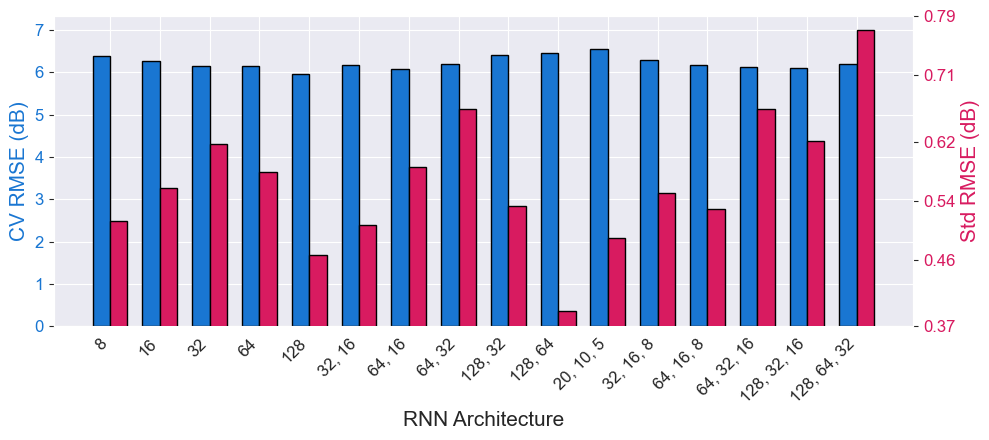

In [7]:
# FONT SIZES 
tick_fontsize = 12
axis_labelsize = 15

sns.set_style("darkgrid")

def arch_to_tuple(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return tuple(int(x) for x in v)
    return tuple(int(x.strip()) for x in str(v).replace("[", "").replace("]", "").replace("(", "").replace(")", "").split(",") if x.strip())

def tuple_to_label(t):
    return ", ".join(map(str, t))

model_results_df_filtered_sorted = model_results_df_sorted.copy()
model_results_df_filtered_sorted["arch_tuple"] = model_results_df_filtered_sorted["Hidden Layers"].apply(arch_to_tuple)
model_results_df_filtered_sorted["Total Nodes"] = model_results_df_filtered_sorted["arch_tuple"].apply(sum)
model_results_df_filtered_sorted["Number of Hidden Layers"] = model_results_df_filtered_sorted["arch_tuple"].apply(len)
model_results_df_filtered_sorted["Test RMSE"] = pd.to_numeric(model_results_df_filtered_sorted["Test RMSE"], errors="coerce")
model_results_df_filtered_sorted["Std RMSE"] = pd.to_numeric(model_results_df_filtered_sorted["Std RMSE"], errors="coerce")

model_results_df_filtered_sorted = model_results_df_filtered_sorted.loc[model_results_df_filtered_sorted.groupby("arch_tuple")["Test RMSE"].idxmin()].copy()
model_results_df_filtered_sorted = model_results_df_filtered_sorted.sort_values(by=["Number of Hidden Layers", "Total Nodes"], ascending=[True, True]).reset_index(drop=True)
model_results_df_filtered_sorted["arch_label"] = model_results_df_filtered_sorted["arch_tuple"].apply(tuple_to_label)

x = np.arange(len(model_results_df_filtered_sorted))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 4.5))

rmse_color = "#1976d2"
std_color  = "#d81b60"

ax1.bar(x - bar_width/2, model_results_df_filtered_sorted["Test RMSE"], bar_width, color=rmse_color, edgecolor="black", linewidth=1, zorder=3)

ax1.set_xlabel("RNN Architecture", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(model_results_df_filtered_sorted["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)

ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color=rmse_color)
ax1.tick_params(axis="y", labelcolor=rmse_color, labelsize=tick_fontsize)
ax1.grid(True, axis="y")
ax1.set_ylim(0, model_results_df_filtered_sorted["Test RMSE"].max() * 1.12)

ax2 = ax1.twinx()
ax2.bar(x + bar_width/2, model_results_df_filtered_sorted["Std RMSE"], bar_width, color=std_color, edgecolor="black", linewidth=1, zorder=3)

ax2.set_ylabel("Std RMSE (dB)", fontsize=axis_labelsize, color=std_color)
ax2.tick_params(axis="y", labelcolor=std_color, labelsize=tick_fontsize)
ax2.grid(False)

std = model_results_df_filtered_sorted["Std RMSE"].astype(float).to_numpy()
std_min, std_max = float(std.min()), float(std.max())
pad = 0.05 * (std_max - std_min) if std_max > std_min else 0.05
std_low, std_high = max(0.0, std_min - pad), std_max + pad

ax2.set_ylim(std_low, std_high)
ax2.set_yticks(np.round(np.linspace(std_low, std_high, 6), 2))

fig.tight_layout()
plt.show()

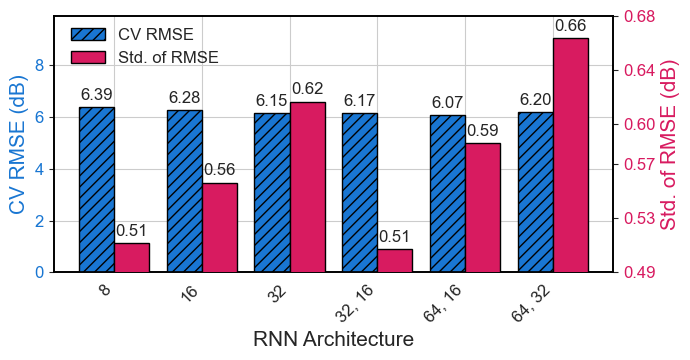

Saved figure: Figures\RNN_RMSE_STD_selected_archs.png


In [8]:
# FONT SIZE METRICS 
tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

# GLOBAL FONT FAMILY: Times New Roman 
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"

sns.set_style("whitegrid")

# keep ONLY these architectures 
TARGET_ARCHS = [
    (8,),
    (16,),
    (32,),
    (32, 16),
    (64, 16),
    (64, 32),
]

def arch_to_tuple(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return tuple(int(x) for x in v)
    nums = re.findall(r"\d+", str(v))
    return tuple(int(n) for n in nums)

def tuple_to_label(t):
    return ", ".join(map(str, t))

# build plot df 
df_plot = model_results_df_sorted.copy()
df_plot["arch_tuple"] = df_plot["Hidden Layers"].apply(arch_to_tuple)
df_plot["Test RMSE"] = pd.to_numeric(df_plot["Test RMSE"], errors="coerce")
df_plot["Std RMSE"] = pd.to_numeric(df_plot["Std RMSE"], errors="coerce")

if "Total Nodes" not in df_plot.columns:
    df_plot["Total Nodes"] = df_plot["arch_tuple"].apply(lambda t: int(np.sum(t)))

df_plot["Number of Hidden Layers"] = df_plot["arch_tuple"].apply(len)

# Filter to target dense architectures; keep best RNN-unit setting per dense architecture.
df_plot = df_plot[df_plot["arch_tuple"].isin(TARGET_ARCHS)].copy()
df_plot = df_plot.loc[df_plot.groupby("arch_tuple")["Test RMSE"].idxmin()].copy()
df_plot = df_plot.sort_values(by=["Number of Hidden Layers", "Total Nodes"], ascending=[True, True]).reset_index(drop=True)
df_plot["arch_label"] = df_plot["arch_tuple"].apply(tuple_to_label)

if df_plot.empty:
    raise ValueError("No rows matched TARGET_ARCHS after filtering. Check 'Hidden Layers' formatting.")

# twin-axis bars 
x = np.arange(len(df_plot))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.7))

rmse_color = "#1976d2"
std_color  = "#d81b60"

bars1 = ax1.bar(x - bar_width / 2, df_plot["Test RMSE"].astype(float), bar_width, color=rmse_color, edgecolor="black", linewidth=1, zorder=3)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("RNN Architecture", fontsize=axis_labelsize)
ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color=rmse_color)
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor=rmse_color, labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width / 2, df_plot["Std RMSE"].astype(float), bar_width, color=std_color, edgecolor="black", linewidth=1, zorder=3)
ax2.set_ylabel("Std. of RMSE (dB)", fontsize=axis_labelsize, color=std_color)
ax2.tick_params(axis="y", labelcolor=std_color, labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(df_plot["Test RMSE"].max()) * 1.55)

std = df_plot["Std RMSE"].astype(float).to_numpy()
std_min, std_max = float(std.min()), float(std.max())
pad = 0.10 * (std_max - std_min) if std_max > std_min else 0.10
std_low, std_high = max(0.0, std_min - pad), std_max + pad
ax2.set_ylim(std_low, std_high)
ax2.set_yticks(np.round(np.linspace(std_low, std_high, 6), 2))

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=rmse_color, edgecolor="black", hatch="///", label="CV RMSE"),
    plt.Rectangle((0, 0), 1, 1, facecolor=std_color, edgecolor="black", label="Std. of RMSE"),
]
leg = ax1.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.02, 0.98), borderaxespad=0.0, fontsize=legend_fontsize, frameon=False)

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "RNN_RMSE_STD_selected_archs.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")